# HDR Point Evaluation with Uncertainties

This notebook demonstrates how to evaluate whether a specific point lies within the HDR (Highest Density Region) and estimate the uncertainty in that determination.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from coppuccino.copula_flows import normalizing_flows_fit, sample_and_log_prob, log_prob
from coppuccino.hdr import (
    compute_hdr, 
    evaluate_point_in_hdr,
    hdr_threshold_uncertainty_bootstrap,
    hdr_threshold_uncertainty_flow_ensemble,
    hdr_threshold_uncertainty
)

## 1. Generate Test Data

We'll use a bivariate Gaussian distribution with correlation.

In [2]:
# Set random seed
np.random.seed(42)

# Define distribution
mean = np.array([1.0, 2.0])
cov = np.array([[2.0, 1.2],
                [1.2, 1.5]])

# Generate samples
n_samples = 3000
samples = np.random.multivariate_normal(mean, cov, n_samples)

print(f"Generated {n_samples} samples")
print(f"Mean: {mean}")
print(f"Covariance:\n{cov}")

Generated 3000 samples
Mean: [1. 2.]
Covariance:
[[2.  1.2]
 [1.2 1.5]]


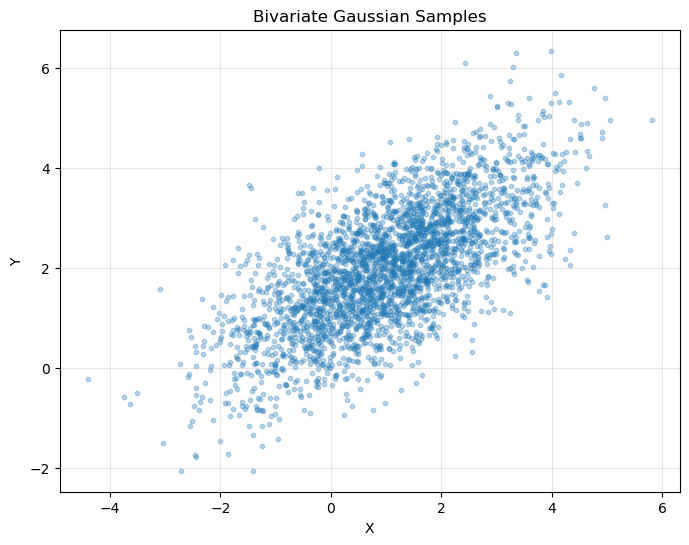

In [3]:
# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=10)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Bivariate Gaussian Samples')
plt.grid(True, alpha=0.3)
plt.show()

## 2. Fit Copula Flow

In [4]:
# Fit flow
flow = normalizing_flows_fit(samples, rng_seed=42)
print("Flow fitted successfully!")

 16%|█▌        | 16/100 [00:03<00:17,  4.80it/s, train=2.5, val=2.64 (Max patience reached)]

Flow fitted successfully!


## 3. Define Test Points

We'll test several points:
- One near the mean (should be well inside HDR)
- One at moderate distance (near the boundary)
- One far from the mean (should be outside HDR)

In [5]:
# Test points
test_points = {
    'Near Mean': np.array([1.0, 2.0]),
    'Moderate Distance': np.array([3.0, 3.5]),
    'Far from Mean': np.array([5.0, 6.0])
}

print("Test points:")
for name, point in test_points.items():
    print(f"  {name}: {point}")

Test points:
  Near Mean: [1. 2.]
  Moderate Distance: [3.  3.5]
  Far from Mean: [5. 6.]


## 4. Compute HDR Threshold with Bootstrap Uncertainty

We'll use bootstrap resampling to estimate the uncertainty in the HDR threshold.

In [6]:
# Generate samples for HDR estimation
credible_level = 0.95
n_hdr_samples = 50000
flow_samples, flow_log_probs = sample_and_log_prob(flow, n_hdr_samples, rng_seed=999)

# Compute HDR with bootstrap uncertainty
uncertainty_bootstrap = hdr_threshold_uncertainty_bootstrap(
    flow,
    credible_level=credible_level,
    samples=flow_samples,
    log_probs=flow_log_probs,
    n_bootstrap=1000,
    confidence_level=0.68,
    rng_seed=42
)

print(f"\n95% HDR Threshold Estimation (Bootstrap):")
print(f"  Threshold: {uncertainty_bootstrap['threshold']:.6f}")
print(f"  Std Dev: {uncertainty_bootstrap['std']:.6f}")
print(f"  68% CI: [{uncertainty_bootstrap['lower']:.6f}, {uncertainty_bootstrap['upper']:.6f}]")


95% HDR Threshold Estimation (Bootstrap):
  Threshold: -5.034628
  Std Dev: 0.021757
  68% CI: [-5.055128, -5.010541]


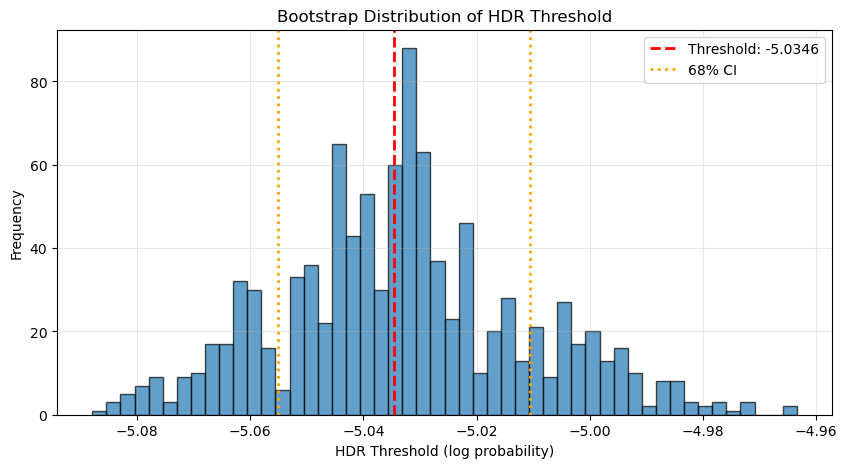

In [7]:
# Visualize bootstrap distribution
plt.figure(figsize=(10, 5))
plt.hist(uncertainty_bootstrap['bootstrap_thresholds'], bins=50, alpha=0.7, edgecolor='black')
plt.axvline(uncertainty_bootstrap['threshold'], color='red', linestyle='--', 
            linewidth=2, label=f"Threshold: {uncertainty_bootstrap['threshold']:.4f}")
plt.axvline(uncertainty_bootstrap['lower'], color='orange', linestyle=':', 
            linewidth=2, label=f"68% CI")
plt.axvline(uncertainty_bootstrap['upper'], color='orange', linestyle=':', linewidth=2)
plt.xlabel('HDR Threshold (log probability)')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of HDR Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Evaluate Test Points with Uncertainties

For each test point, we'll:
1. Compute its log probability under the flow
2. Compare it to the HDR threshold
3. Assess the confidence in the determination based on uncertainty

In [8]:
# Evaluate each test point
print("\n" + "="*80)
print("POINT EVALUATION WITH UNCERTAINTIES")
print("="*80)

results = {}

for name, point in test_points.items():
    # Compute log probability of the point
    point_log_prob = log_prob(flow, point.reshape(1, -1))[0]
    
    # Check if in HDR using point estimate
    in_hdr_point = point_log_prob >= uncertainty_bootstrap['threshold']
    
    # Compute how many standard deviations from threshold
    n_sigma = (point_log_prob - uncertainty_bootstrap['threshold']) / uncertainty_bootstrap['std']
    
    # Check against confidence interval bounds
    definitely_in = point_log_prob >= uncertainty_bootstrap['upper']
    definitely_out = point_log_prob < uncertainty_bootstrap['lower']
    uncertain = not (definitely_in or definitely_out)
    
    # Estimate probability of being in HDR using normal approximation
    prob_in_hdr = stats.norm.cdf(n_sigma)
    
    results[name] = {
        'point': point,
        'log_prob': point_log_prob,
        'in_hdr': in_hdr_point,
        'n_sigma': n_sigma,
        'definitely_in': definitely_in,
        'definitely_out': definitely_out,
        'uncertain': uncertain,
        'prob_in_hdr': prob_in_hdr
    }
    
    print(f"\n{name}:")
    print(f"  Point: {point}")
    print(f"  Log probability: {point_log_prob:.6f}")
    print(f"  HDR threshold: {uncertainty_bootstrap['threshold']:.6f} ± {uncertainty_bootstrap['std']:.6f}")
    print(f"  Distance from threshold: {n_sigma:.2f} σ")
    print(f"  Point estimate: {'IN HDR' if in_hdr_point else 'OUTSIDE HDR'}")
    
    if definitely_in:
        print(f"  Confidence: HIGH (definitely in HDR)")
    elif definitely_out:
        print(f"  Confidence: HIGH (definitely outside HDR)")
    else:
        print(f"  Confidence: UNCERTAIN (near boundary)")
    
    print(f"  Estimated probability in HDR: {prob_in_hdr:.1%}")

print("\n" + "="*80)


POINT EVALUATION WITH UNCERTAINTIES

Near Mean:
  Point: [1. 2.]
  Log probability: -2.428674
  HDR threshold: -5.034628 ± 0.021757
  Distance from threshold: 119.78 σ
  Point estimate: IN HDR
  Confidence: HIGH (definitely in HDR)
  Estimated probability in HDR: 100.0%

Moderate Distance:
  Point: [3.  3.5]
  Log probability: -3.287194
  HDR threshold: -5.034628 ± 0.021757
  Distance from threshold: 80.32 σ
  Point estimate: IN HDR
  Confidence: HIGH (definitely in HDR)
  Estimated probability in HDR: 100.0%

Far from Mean:
  Point: [5. 6.]
  Log probability: -7.338452
  HDR threshold: -5.034628 ± 0.021757
  Distance from threshold: -105.89 σ
  Point estimate: OUTSIDE HDR
  Confidence: HIGH (definitely outside HDR)
  Estimated probability in HDR: 0.0%



## 6. Alternative: Flow Ensemble Uncertainty

We can also estimate uncertainty by generating multiple independent sample sets from the flow.

In [9]:
# Compute uncertainty using flow ensemble
uncertainty_ensemble = hdr_threshold_uncertainty_flow_ensemble(
    flow,
    credible_level=credible_level,
    n_samples_per_draw=20000,
    n_draws=100,
    rng_seed=42,
    confidence_level=0.68
)

print(f"\n95% HDR Threshold Estimation (Flow Ensemble):")
print(f"  Mean threshold: {uncertainty_ensemble['threshold_mean']:.6f}")
print(f"  Median threshold: {uncertainty_ensemble['threshold_median']:.6f}")
print(f"  Std Dev: {uncertainty_ensemble['std']:.6f}")
print(f"  Std Error: {uncertainty_ensemble['stderr']:.6f}")
print(f"  68% CI: [{uncertainty_ensemble['lower']:.6f}, {uncertainty_ensemble['upper']:.6f}]")


95% HDR Threshold Estimation (Flow Ensemble):
  Mean threshold: -5.047462
  Median threshold: -5.047171
  Std Dev: 0.031939
  Std Error: 0.003194
  68% CI: [-5.081083, -5.014430]


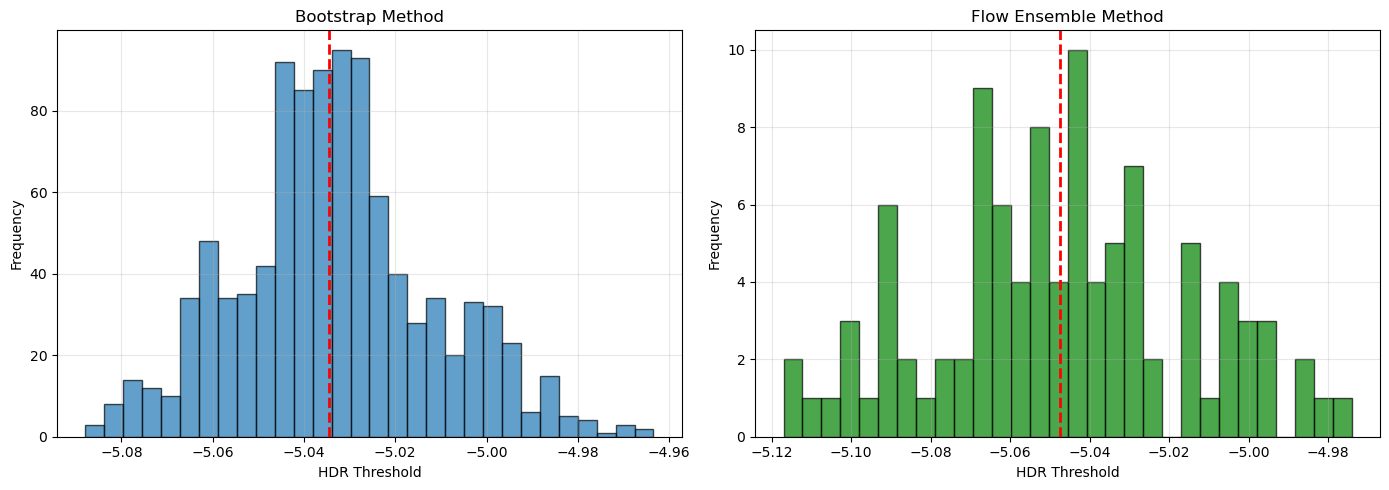


Comparison:
  Bootstrap std: 0.021757
  Ensemble std: 0.031939
  Ratio: 0.68


In [10]:
# Compare bootstrap vs flow ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(uncertainty_bootstrap['bootstrap_thresholds'], bins=30, alpha=0.7, 
        edgecolor='black', label='Bootstrap')
ax.axvline(uncertainty_bootstrap['threshold'], color='red', linestyle='--', linewidth=2)
ax.set_xlabel('HDR Threshold')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Method')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(uncertainty_ensemble['thresholds'], bins=30, alpha=0.7, 
        edgecolor='black', color='green', label='Flow Ensemble')
ax.axvline(uncertainty_ensemble['threshold_mean'], color='red', linestyle='--', linewidth=2)
ax.set_xlabel('HDR Threshold')
ax.set_ylabel('Frequency')
ax.set_title('Flow Ensemble Method')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nComparison:")
print(f"  Bootstrap std: {uncertainty_bootstrap['std']:.6f}")
print(f"  Ensemble std: {uncertainty_ensemble['std']:.6f}")
print(f"  Ratio: {uncertainty_bootstrap['std'] / uncertainty_ensemble['std']:.2f}")

## 7. Visualize Points Relative to HDR with Uncertainty Band

/var/folders/8d/436xvw6j6g13_xm6nrrvwv7c0000gn/T/ipykernel_35006/3660413502.py:19: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, grid_log_probs,
/var/folders/8d/436xvw6j6g13_xm6nrrvwv7c0000gn/T/ipykernel_35006/3660413502.py:23: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, grid_log_probs,
/var/folders/8d/436xvw6j6g13_xm6nrrvwv7c0000gn/T/ipykernel_35006/3660413502.py:27: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, grid_log_probs,


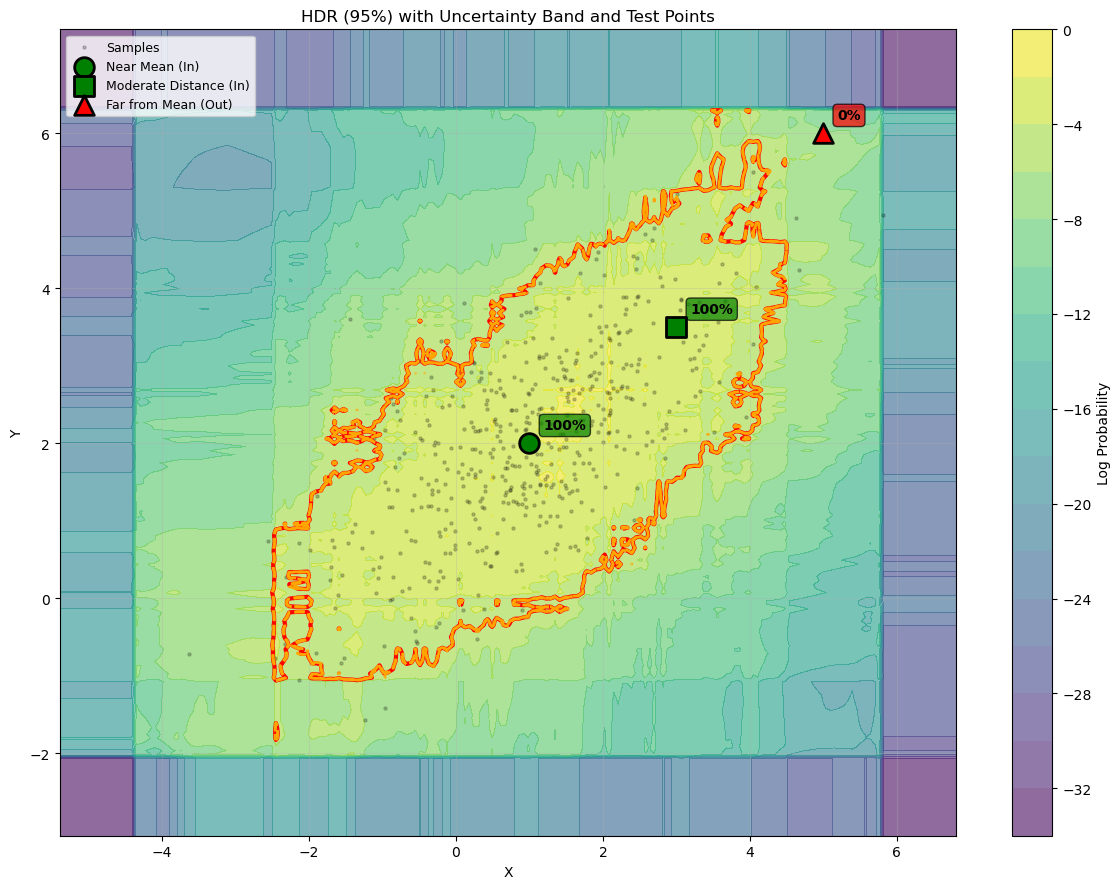

In [11]:
# Create grid for visualization
x_min, x_max = samples[:, 0].min() - 1, samples[:, 0].max() + 1
y_min, y_max = samples[:, 1].min() - 1, samples[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Compute log probabilities on grid
grid_log_probs = log_prob(flow, grid_points).reshape(xx.shape)

# Plot
plt.figure(figsize=(12, 9))

# Contour plot of log probability
contour = plt.contourf(xx, yy, grid_log_probs, levels=20, cmap='viridis', alpha=0.6)
plt.colorbar(contour, label='Log Probability')

# HDR boundary with uncertainty band
plt.contour(xx, yy, grid_log_probs, 
           levels=[uncertainty_bootstrap['threshold']], 
           colors='red', linewidths=3, linestyles='-', 
           label=f"HDR boundary ({credible_level:.0%})")
plt.contour(xx, yy, grid_log_probs, 
           levels=[uncertainty_bootstrap['lower']], 
           colors='orange', linewidths=2, linestyles='--', 
           label='68% CI (lower)')
plt.contour(xx, yy, grid_log_probs, 
           levels=[uncertainty_bootstrap['upper']], 
           colors='orange', linewidths=2, linestyles='--', 
           label='68% CI (upper)')

# Plot samples
plt.scatter(samples[:500, 0], samples[:500, 1], alpha=0.2, s=5, c='black', label='Samples')

# Plot test points with colors based on determination
colors = {'definitely_in': 'green', 'definitely_out': 'red', 'uncertain': 'yellow'}
markers = {'Near Mean': 'o', 'Moderate Distance': 's', 'Far from Mean': '^'}

for name, result in results.items():
    if result['definitely_in']:
        color = 'green'
        status = 'In'
    elif result['definitely_out']:
        color = 'red'
        status = 'Out'
    else:
        color = 'yellow'
        status = 'Uncertain'
    
    plt.scatter(result['point'][0], result['point'][1], 
               s=200, c=color, marker=markers[name], 
               edgecolors='black', linewidths=2, zorder=5,
               label=f"{name} ({status})")
    
    # Add annotation
    plt.annotate(f"{result['prob_in_hdr']:.0%}", 
                xy=result['point'], 
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7))

plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'HDR ({credible_level:.0%}) with Uncertainty Band and Test Points')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary Table

In [12]:
import pandas as pd

# Create summary table
summary_data = []
for name, result in results.items():
    summary_data.append({
        'Point': name,
        'Coordinates': f"({result['point'][0]:.1f}, {result['point'][1]:.1f})",
        'Log Prob': f"{result['log_prob']:.4f}",
        'Distance (σ)': f"{result['n_sigma']:+.2f}",
        'Determination': 'In HDR' if result['in_hdr'] else 'Outside',
        'Confidence': 'High' if (result['definitely_in'] or result['definitely_out']) else 'Uncertain',
        'P(in HDR)': f"{result['prob_in_hdr']:.1%}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY TABLE")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)
print(f"\nHDR Threshold: {uncertainty_bootstrap['threshold']:.4f} ± {uncertainty_bootstrap['std']:.4f}")
print(f"68% Confidence Interval: [{uncertainty_bootstrap['lower']:.4f}, {uncertainty_bootstrap['upper']:.4f}]")


SUMMARY TABLE
            Point Coordinates Log Prob Distance (σ) Determination Confidence P(in HDR)
        Near Mean  (1.0, 2.0)  -2.4287      +119.78        In HDR       High    100.0%
Moderate Distance  (3.0, 3.5)  -3.2872       +80.32        In HDR       High    100.0%
    Far from Mean  (5.0, 6.0)  -7.3385      -105.89       Outside       High      0.0%

HDR Threshold: -5.0346 ± 0.0218
68% Confidence Interval: [-5.0551, -5.0105]


## Summary

This notebook demonstrated:

1. **HDR Threshold Estimation with Uncertainties**: Used bootstrap and flow ensemble methods to quantify uncertainty in the HDR boundary

2. **Point Evaluation with Confidence**: For each test point, we:
   - Computed its log probability under the flow
   - Compared it to the HDR threshold and uncertainty bounds
   - Calculated the distance from the threshold in units of standard deviation
   - Estimated the probability that the point is truly within the HDR
   - Classified confidence level (high vs uncertain)

3. **Visualization**: Created plots showing:
   - The HDR boundary with uncertainty bands
   - Test points colored by confidence in their classification
   - Probability annotations for each point

**Key Insights**:
- Points far from the threshold have high confidence in their classification
- Points near the threshold (within ~1σ) are uncertain and require careful interpretation
- Both bootstrap and flow ensemble methods provide similar uncertainty estimates
- The probability that a point is in the HDR can be estimated from its distance to the threshold in units of the threshold uncertainty